# PMT 850 V, 525 MHz bandwidth, LED1

This notebook uses the reusable `pmt_analysis.py` helpers for the full PMT LED workflow:

1. read the Keysight segmented HDF5 files,
2. subtract the baseline,
3. check the baseline removal,
4. compute pulse charge in `mV ns`,
5. fit the SPE charge spectrum.

The charge convention is `charge_mV_ns = - integral(V_baseline_subtracted dt)`, so negative-going PMT pulses have positive charge.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pmt_analysis import (
    compute_charges_for_windows,
    fit_spe_spectrum,
    print_spe_fit_result,
    read_keysight_h5_direct,
    spe_poisson_components,
    spe_poisson_model,
    standard_units,
    subtract_baseline,
    summarize_waveforms,
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [2]:
data_dir = Path("data/calibLED/lightsoff")
led1_files = sorted(data_dir.glob("baseline850V_BW525MHz_led1-*.h5"))

if not led1_files:
    raise FileNotFoundError("No 525 MHz LED1 files found")

for file in led1_files:
    print(file)
print(f"Number of files: {len(led1_files)}")

data/calibLED/lightsoff/baseline850V_BW525MHz_led1-1.h5
data/calibLED/lightsoff/baseline850V_BW525MHz_led1-2.h5
data/calibLED/lightsoff/baseline850V_BW525MHz_led1-3.h5
data/calibLED/lightsoff/baseline850V_BW525MHz_led1-4.h5
Number of files: 4


In [3]:
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    led1_files[0],
    segment_numbers=range(5000),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (4999, 7993)
Time range: 13.735 to 76.173 ns
Sampling step: 0.00781 ns
ADC step: 0.001276 mV


In [60]:
## config
# baseline_window_ns = (14.0, 30.0)
# integration_window_ns = (36.0, 50.0)

baseline_window_ns = (14.0, 27.0)
integration_window_ns = (29.0, 45.0)
threshold_mV = -5. # threshold to compute mean waveform (if no cut, the baseline dominates)

/var/folders/80/x5l9nnmd2gb3szz23pnjrgpm0000gn/T/ipykernel_20736/811099428.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/Lab-tools/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/Lab-tools/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


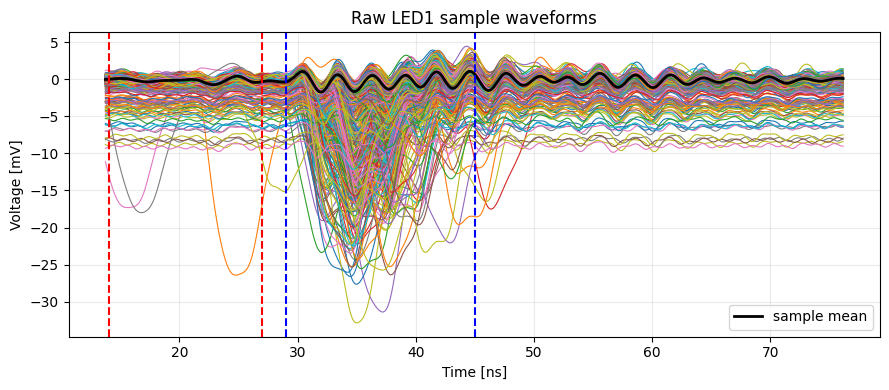

In [6]:
show_wfs = True
maxEvts = 5000

fig, ax = plt.subplots(figsize=(9, 4))
for waveform in voltage_sample_mV[:maxEvts]:
    if show_wfs:
        ax.plot(time_ns, waveform, lw=0.8) # the "color="0.45", alpha=0.12, lw=0.8" is what makes it look like that
    else:
        ax.plot(time_ns, waveform, color="0.45", alpha=0.12, lw=0.8)
ax.plot(time_ns, voltage_sample_mV[:maxEvts].mean(axis=0), color="black", lw=2, label="sample mean")
ax.axvline(x = baseline_window_ns[0], color="red", linestyle="--")
ax.axvline(x = baseline_window_ns[1], color="red", linestyle="--")

ax.axvline(x = integration_window_ns[0], color="blue", linestyle="--")
ax.axvline(x = integration_window_ns[1], color="blue", linestyle="--")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Voltage [mV]")
ax.set_title("Raw LED1 sample waveforms")
ax.legend()
fig.tight_layout()

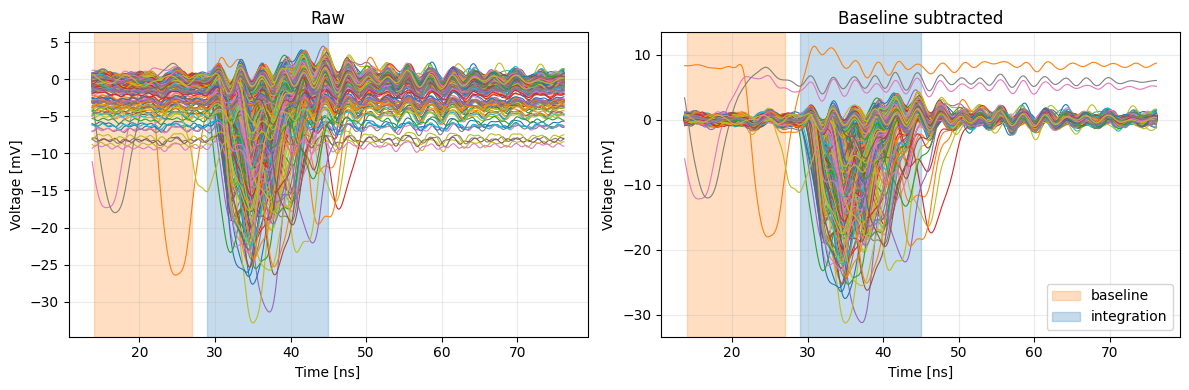

In [7]:
show_wfs = True
maxEvts = 5000

voltage_sample_bs_mV, sample_baseline_mV = subtract_baseline(
    time_ns,
    voltage_sample_mV,
    baseline_window_ns=baseline_window_ns,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for waveform in voltage_sample_mV[:maxEvts]:
    if show_wfs:
        axes[0].plot(time_ns, waveform, lw=0.8)
    else:
        axes[0].plot(time_ns, waveform, color="0.45", alpha=0.12, lw=0.8)
for waveform in voltage_sample_bs_mV[:maxEvts]:
    if show_wfs:
        axes[1].plot(time_ns, waveform, lw=0.8)
    else:
        axes[1].plot(time_ns, waveform, color="tab:blue", alpha=0.12, lw=0.8)

for ax in axes:
    ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    ax.axvspan(*integration_window_ns, color="tab:blue", alpha=0.25, label="integration")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")
axes[0].set_title("Raw")
axes[1].set_title("Baseline subtracted")
axes[1].legend(loc="lower right")
fig.tight_layout()

In [8]:
summary = summarize_waveforms(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
)

mean_waveform = summary["mean_waveform_mV"]
idx_min = int(np.argmin(mean_waveform))

print(f"Processed events: {summary['n_events']}")
print(f"Baseline window: {baseline_window_ns[0]:.1f}-{baseline_window_ns[1]:.1f} ns")
print(f"Baseline mean/std: {np.mean(summary['baseline_mV']):.4f} +/- {np.std(summary['baseline_mV']):.4f} mV")
print(f"Residual in baseline window: {np.mean(summary['baseline_check_mV']):.3e} +/- {np.std(summary['baseline_check_mV']):.3e} mV")
print(f"Mean waveform minimum: {summary['time_ns'][idx_min]:.3f} ns, {mean_waveform[idx_min]:.4f} mV")

Processed events: 126728
Baseline window: 14.0-27.0 ns
Baseline mean/std: -0.1260 +/- 0.2733 mV
Residual in baseline window: -2.376e-09 +/- 3.297e-07 mV
Mean waveform minimum: 46.154 ns, -0.9704 mV


In [30]:
def select_threshold( voltage_mV, threshold_mV=-0.5 ):

    mask = np.any(
        voltage_mV < threshold_mV,
        axis=1
    )

    selection = voltage_mV[mask]
    n_selected = np.sum(mask)
    efficiency = n_selected / len(voltage_mV)

    return selection, efficiency, n_selected

0.04980996199239848 249


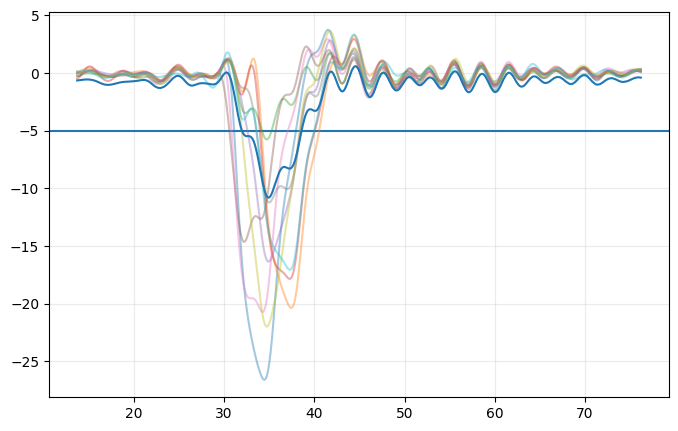

In [61]:
# threshold_mV = -5.
sel, eff, nSel = select_threshold( voltage_sample_mV, threshold_mV=threshold_mV )
print(eff, nSel)
mean_waveform_withCut = np.mean(sel, axis=0)

# for i in range(0, 10):
#     plt.plot(time_ns, voltage_sample_mV[i], alpha=0.4)
plt.axhline(y=threshold_mV)
for s in sel[:10]:
    plt.plot(time_ns, s, alpha=0.4)

    
plt.plot(time_ns, mean_waveform_withCut);


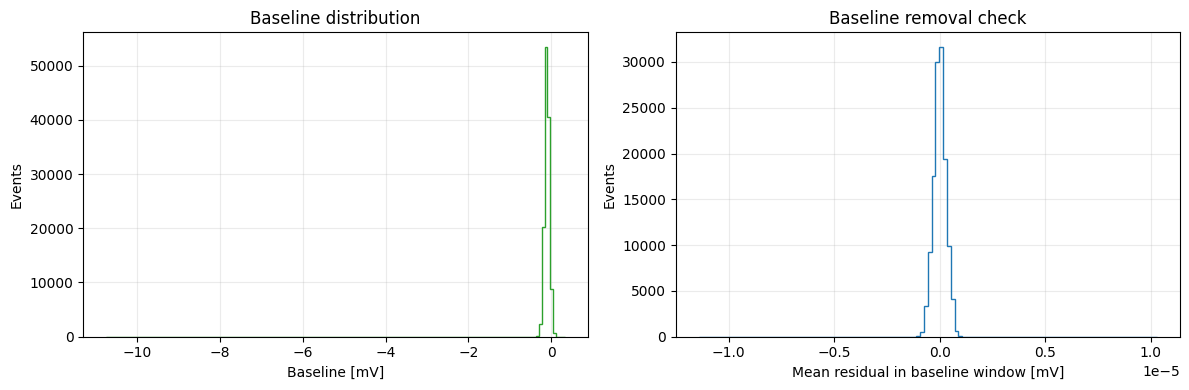

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summary["baseline_mV"], bins=160, histtype="step", color="tab:green")
axes[0].set_xlabel("Baseline [mV]")
axes[0].set_ylabel("Events")
axes[0].set_title("Baseline distribution")

axes[1].hist(summary["baseline_check_mV"], bins=120, histtype="step", color="tab:blue")
axes[1].set_xlabel("Mean residual in baseline window [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Baseline removal check")
fig.tight_layout()

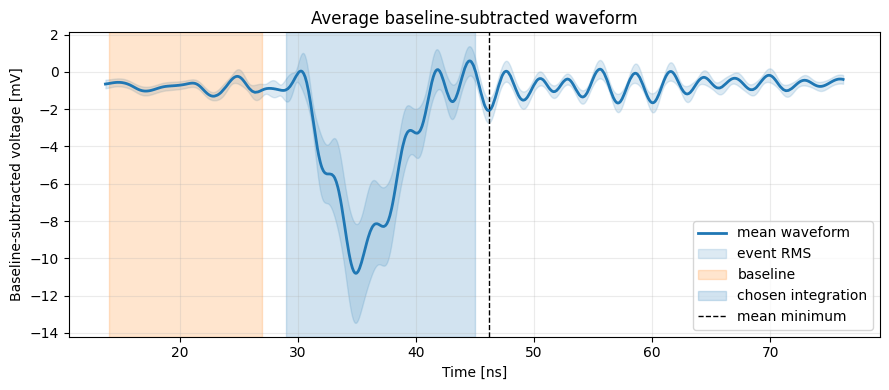

In [63]:
fig, ax = plt.subplots(figsize=(9, 4))


mean_waveform = mean_waveform_withCut

ax.plot(summary["time_ns"], mean_waveform, color="tab:blue", lw=2, label="mean waveform")
ax.fill_between(
    summary["time_ns"],
    mean_waveform - summary["std_waveform_mV"],
    mean_waveform + summary["std_waveform_mV"],
    color="tab:blue",
    alpha=0.15,
    label="event RMS",
)
ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.20, label="baseline")
ax.axvspan(*integration_window_ns, color="tab:blue", alpha=0.20, label="chosen integration")
ax.axvline(summary["time_ns"][idx_min], color="black", ls="--", lw=1, label="mean minimum")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Average baseline-subtracted waveform")
ax.legend(loc="best")
fig.tight_layout()

In [65]:
print(baseline_window_ns, integration_window_ns)

(14.0, 27.0) (29.0, 45.0)


In [66]:
# candidate_windows_ns = [
#     (36.0, 50.0),
#     (38.0, 50.0),
#     (40.0, 52.0),
#     (42.0, 52.0),
#     (40.0, 58.0),
# ]

candidate_windows_ns = [
    (25.0, 50.0),
    (29.0, 45.0),
    (29.0, 50.0),
    (30.0, 45.0),
    (30.0, 50.0),
]

charges_by_window = compute_charges_for_windows(
    led1_files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=candidate_windows_ns,
    chunk_size=4096,
)

print("Candidate fixed-window charges")
print("window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]")
for window, charge_values in charges_by_window.items():
    q = np.quantile(charge_values, [0.001, 0.01, 0.5, 0.90, 0.99, 0.999])
    print(
        f"{window[0]:4.0f}-{window[1]:<4.0f}"
        f" {q[0]:10.3f} {q[1]:9.3f} {q[2]:9.3f} {q[3]:9.3f} {q[4]:9.3f} {q[5]:9.3f}"
    )

Candidate fixed-window charges
window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]
  25-50       -5.172    -3.499    -0.177     1.930    78.775   116.770
  29-45       -4.857    -3.610    -1.138     0.428    77.404   116.519
  29-50       -5.188    -3.520    -0.450     1.488    78.629   116.746
  30-45       -4.378    -3.183    -0.509     1.212    77.896   116.920
  30-50       -4.539    -2.949     0.161     2.138    79.010   117.446


In [68]:
charge_mV_ns = charges_by_window[integration_window_ns]

print(f"Selected integration window: {integration_window_ns[0]:.1f}-{integration_window_ns[1]:.1f} ns")
print("Charge quantiles [mV ns]:")
for prob, value in zip(
    [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
    np.quantile(charge_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
):
    print(f"  q{prob:0.3f}: {value:9.4f}")

Selected integration window: 29.0-45.0 ns
Charge quantiles [mV ns]:
  q0.001:   -4.8572
  q0.010:   -3.6097
  q0.100:   -2.4685
  q0.500:   -1.1383
  q0.900:    0.4281
  q0.990:   77.4037
  q0.999:  116.5187


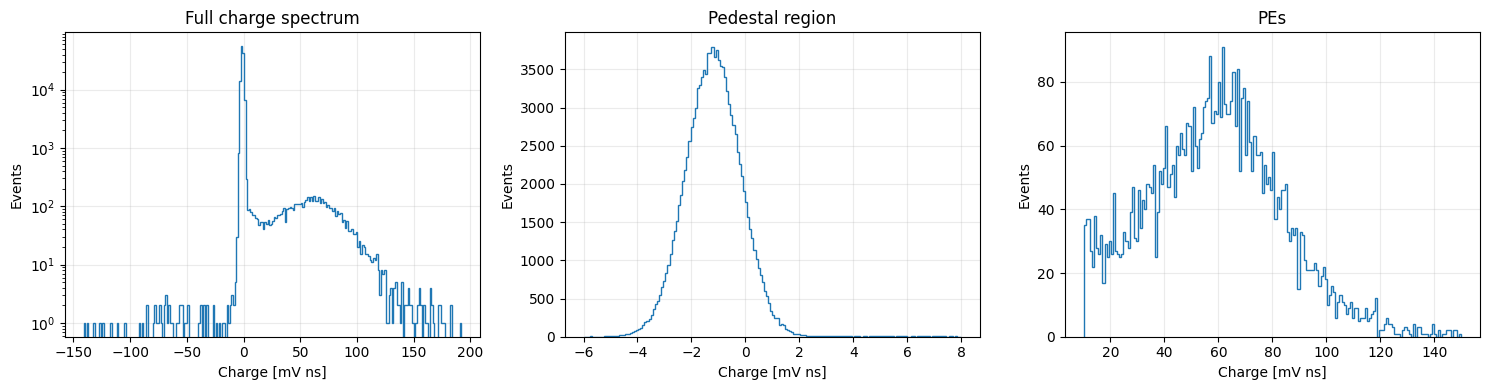

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(charge_mV_ns, bins=240, histtype="step")
axes[0].set_xlabel("Charge [mV ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Full charge spectrum")
axes[0].set_yscale('log')

axes[1].hist(charge_mV_ns, bins=180, range=(-6, 8), histtype="step")
axes[1].set_xlabel("Charge [mV ns]")
axes[1].set_ylabel("Events")
axes[1].set_title("Pedestal region")

axes[2].hist(charge_mV_ns, bins=180, range=(10, 150), histtype="step")
axes[2].set_xlabel("Charge [mV ns]")
axes[2].set_ylabel("Events")
axes[2].set_title("PEs")
# axes[2].set_yscale('log')
fig.tight_layout()

In [95]:
fit = fit_spe_spectrum(
    charge_mV_ns,
    fit_range=(-6.0, 150.0),
    bins=250,
    min_spe_area_mV_ns=2.0,
)
print_spe_fit_result(fit)

if fit["diagnostics"]:
    print("\nFit note: the 525 MHz spectrum is pedestal dominated and the SPE parameters are weakly constrained.")
else:
    print("\nFit note: no fit-bound warnings were raised.")

n_total: 126115 +/- 3.6e+02
pedestal_mV_ns: -1.20327 +/- 0.003
sigma_pedestal_mV_ns: 1.02846 +/- 0.0021
spe_area_mV_ns: 55.1097 +/- 0.44
sigma_spe_mV_ns: 26.7907 +/- 0.37
mu_led: 0.04667 +/- 0.00063
chi2/ndof: 613.2/244 = 2.513

Fit note: no fit-bound warnings were raised.


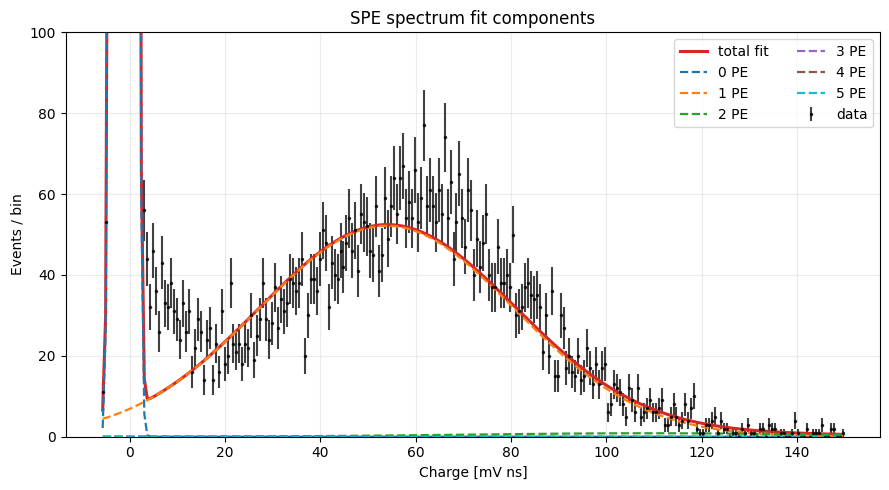

In [102]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    fit["centers"],
    fit["counts"],
    yerr=np.sqrt(np.maximum(fit["counts"], 1)),
    fmt=".",
    ms=3,
    color="black",
    alpha=0.75,
    label="data",
)
ax.plot(fit["centers"], fit["model_counts"], color="tab:red", lw=2.2, label="total fit")

components = spe_poisson_components(
    fit["centers"],
    fit["parameters"]["n_total"],
    fit["parameters"]["pedestal_mV_ns"],
    fit["parameters"]["sigma_pedestal_mV_ns"],
    fit["parameters"]["spe_area_mV_ns"],
    fit["parameters"]["sigma_spe_mV_ns"],
    fit["parameters"]["mu_led"],
    fit["bin_width"],
    max_pe=5,
)

component_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:cyan"]
for n_pe, color in zip(components, component_colors):
    ax.plot(
        fit["centers"],
        components[n_pe],
        ls="--",
        lw=1.6,
        color=color,
        label=f"{n_pe} PE",
    )

ax.set_xlabel("Charge [mV ns]")
ax.set_ylabel("Events / bin")
ax.set_title("SPE spectrum fit components")
# ax.set_yscale("log")
# ax.set_ylim(bottom=0.5)
ax.set_ylim(0., 100.)
ax.legend(ncol=2)
fig.tight_layout()

In [97]:
print("Sanity checks")
print(f"1. Baseline residual is centered near zero: {np.mean(summary['baseline_check_mV']):.3e} mV")
print(f"2. Chosen charge window includes the average pulse minimum at {summary['time_ns'][idx_min]:.3f} ns")
print(f"3. Charge units are mV ns by construction: -integral(V_mV dt_ns)")
print(f"4. SPE fit chi2/ndof = {fit['chi2'] / fit['ndof']:.3f}; treat SPE area as weakly constrained for this run")

Sanity checks
1. Baseline residual is centered near zero: -2.376e-09 mV
2. Chosen charge window includes the average pulse minimum at 46.154 ns
3. Charge units are mV ns by construction: -integral(V_mV dt_ns)
4. SPE fit chi2/ndof = 2.513; treat SPE area as weakly constrained for this run
